# Option 0S - PHE-only 2.5D Fusion-FPN Segmentation

Notebook này đưa hướng Option 0D detection quay lại bài toán **segmentation**.

Ý tưởng kiến trúc vẫn bám theo sơ đồ 2.5D:

```text
Input 2.5D stack N lát cắt
        |
2D CNN backbone cho từng lát
        |
2D feature maps theo từng lát
        |
3D Conv fusion trên stack feature maps
        |
FPN / Neck multi-scale
        |
Segmentation decoder/head
        |
Predict PHE mask
```

Phạm vi:

- PHE-only.
- Không dùng Seg-CQ500.
- Không dùng INSTANCE2022.
- Không dùng teacher prior.
- Reuse patient-level split của Option 1.

## 0. Dependency notes

In [1]:
INSTALL_BASIC_DEPS = False

if INSTALL_BASIC_DEPS:
    import sys
    import subprocess
    pkgs = ["numpy", "pandas", "matplotlib", "scipy", "nibabel", "tqdm", "torchvision"]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", *pkgs])

In [2]:
from pathlib import Path
from dataclasses import dataclass, asdict


@dataclass
class Option0SConfig:
    project_root: Path = Path.cwd()
    seed: int = 42

    # Run switches.
    run_training: bool = True
    run_final_eval: bool = True
    debug_small_run: bool = False
    debug_train_cases: int = 8
    debug_val_cases: int = 4
    debug_test_cases: int = 4
    debug_epochs: int = 2

    # 2.5D input.
    image_size: int = 512
    stack_size: int = 5
    slice_offsets: tuple = (-2, -1, 0, 1, 2)
    brain_window_low: float = -20.0
    brain_window_high: float = 100.0

    # Architecture.
    backbone: str = "resnet18"
    pretrained_backbone: bool = True
    fpn_channels: int = 128
    decoder_channels: tuple = (128, 96, 64, 48)

    # Training.
    epochs: int = 100
    batch_size: int = 2
    grad_accum_steps: int = 2
    lr_backbone: float = 1e-5
    lr_head: float = 5e-5
    weight_decay: float = 1e-4
    patience: int = 20
    min_delta: float = 1e-4
    freeze_backbone_epochs: int = 2
    amp: bool = True
    num_workers: int = 0

    # Imbalance/loss, kept conservative to reduce false positives.
    positive_slice_weight: float = 3.0
    bce_pos_weight_clip: float = 25.0
    lambda_bce: float = 1.0
    lambda_dice: float = 1.0
    lambda_ftv: float = 0.12
    lambda_boundary: float = 0.02
    ftv_alpha: float = 0.55
    ftv_beta: float = 0.45
    ftv_gamma: float = 0.75
    augment_train: bool = True

    # Evaluation/calibration.
    threshold: float = 0.5
    tune_threshold_on_val: bool = True
    threshold_grid: tuple = (
        0.30, 0.35, 0.40, 0.45, 0.50,
        0.55, 0.60, 0.65, 0.70, 0.75,
        0.80, 0.85, 0.90, 0.95,
    )
    threshold_rvd_penalty: float = 0.04
    threshold_volume_mae_penalty: float = 0.005
    nsd_tolerance_mm: float = 1.0
    use_tta_flip: bool = True
    use_postprocess: bool = True
    min_component_ml: float = 0.15
    max_components: int = 3
    keep_largest_component: bool = False
    save_probability_npz: bool = False


CFG = Option0SConfig()
PROJECT_ROOT = CFG.project_root.resolve()

PHE_ROOT = PROJECT_ROOT / "PHE-SICH-CT-IDS" / "SubdatasetA_NIFIT" / "NIFIT"
PHE_IMAGE_DIR = PHE_ROOT / "set"
PHE_MASK_DIR = PHE_ROOT / "label"
OPTION1_SPLIT_PATH = PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "manifests" / "phe_sich_option1_patient_442_split.csv"

OUTPUT_ROOT = PROJECT_ROOT / "outputs_option_0s_phe_only_25d_fusion_fpn_segmentation"
MANIFEST_DIR = OUTPUT_ROOT / "manifests"
TABLE_DIR = OUTPUT_ROOT / "tables"
FIG_DIR = OUTPUT_ROOT / "figures"
CHECKPOINT_DIR = OUTPUT_ROOT / "checkpoints"
PRED_DIR = OUTPUT_ROOT / "predictions"
LOG_DIR = OUTPUT_ROOT / "logs"

for p in [OUTPUT_ROOT, MANIFEST_DIR, TABLE_DIR, FIG_DIR, CHECKPOINT_DIR, PRED_DIR, LOG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

assert CFG.stack_size == len(CFG.slice_offsets), "stack_size must match slice_offsets length"

print("Project root:", PROJECT_ROOT)
print("PHE root    :", PHE_ROOT)
print("Output root :", OUTPUT_ROOT)
print("Backbone    :", CFG.backbone)
print("Stack       :", CFG.slice_offsets)

Project root: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao
PHE root    : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\PHE-SICH-CT-IDS\SubdatasetA_NIFIT\NIFIT
Output root : D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option_0s_phe_only_25d_fusion_fpn_segmentation
Backbone    : resnet18
Stack       : (-2, -1, 0, 1, 2)


In [3]:
import os
import json
import math
import random
import time
from typing import Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

try:
    import nibabel as nib
    NIB_AVAILABLE = True
except Exception as exc:
    nib = None
    NIB_AVAILABLE = False
    print("nibabel unavailable:", exc)

try:
    from scipy import ndimage
    SCIPY_AVAILABLE = True
except Exception as exc:
    ndimage = None
    SCIPY_AVAILABLE = False
    print("scipy unavailable:", exc)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
    TORCH_AVAILABLE = True
except Exception as exc:
    torch = nn = F = Dataset = DataLoader = WeightedRandomSampler = None
    TORCH_AVAILABLE = False
    print("torch unavailable; training/eval cells will skip:", exc)

if TORCH_AVAILABLE:
    try:
        from torchvision.models import resnet18, ResNet18_Weights
        TORCHVISION_AVAILABLE = True
    except Exception as exc:
        resnet18 = ResNet18_Weights = None
        TORCHVISION_AVAILABLE = False
        print("torchvision unavailable; model will skip:", exc)
else:
    resnet18 = ResNet18_Weights = None
    TORCHVISION_AVAILABLE = False


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True


set_seed(CFG.seed)
DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print({"nibabel": NIB_AVAILABLE, "scipy": SCIPY_AVAILABLE, "torch": TORCH_AVAILABLE, "torchvision": TORCHVISION_AVAILABLE, "device": DEVICE})

{'nibabel': True, 'scipy': True, 'torch': True, 'torchvision': True, 'device': 'cuda'}


## 1. Data helpers and Option 1 split

In [4]:
def is_nifti(path: Path) -> bool:
    return path.name.endswith(".nii") or path.name.endswith(".nii.gz")


def strip_nii_suffix(path_or_name) -> str:
    name = Path(path_or_name).name
    if name.endswith(".nii.gz"):
        return name[:-7]
    if name.endswith(".nii"):
        return name[:-4]
    return Path(name).stem


def load_nifti(path: Path, canonical: bool = True):
    if not NIB_AVAILABLE:
        raise ImportError("Install nibabel first.")
    img = nib.load(str(path))
    if canonical:
        img = nib.as_closest_canonical(img)
    data = np.asanyarray(img.dataobj)
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return data, spacing, img.affine


def header_info(path: Path) -> Dict:
    img = nib.load(str(path))
    shape = tuple(int(v) for v in img.shape[:3])
    spacing = tuple(float(v) for v in img.header.get_zooms()[:3])
    return {
        "shape": shape,
        "spacing_x": spacing[0],
        "spacing_y": spacing[1],
        "spacing_z": spacing[2],
        "n_slices": shape[2],
    }


def mask_volume_stats(mask_path: Path, spacing: Tuple[float, float, float]) -> Dict:
    mask = np.asanyarray(nib.load(str(mask_path)).dataobj) > 0
    per_slice = mask.reshape((-1, mask.shape[2])).sum(axis=0)
    voxel_ml = float(np.prod(spacing) / 1000.0)
    return {
        "mask_voxels": int(mask.sum()),
        "mask_volume_ml": float(mask.sum() * voxel_ml),
        "positive_slices": int((per_slice > 0).sum()),
    }


def build_phe_manifest() -> pd.DataFrame:
    if not PHE_IMAGE_DIR.exists() or not PHE_MASK_DIR.exists():
        raise FileNotFoundError(f"PHE folders not found: {PHE_IMAGE_DIR}, {PHE_MASK_DIR}")
    images = {strip_nii_suffix(p): p for p in PHE_IMAGE_DIR.iterdir() if p.is_file() and is_nifti(p)}
    masks = {strip_nii_suffix(p): p for p in PHE_MASK_DIR.iterdir() if p.is_file() and is_nifti(p)}
    rows = []
    for scan_id, img_path in sorted(images.items()):
        mask_path = masks.get(scan_id)
        if mask_path is None:
            continue
        info = header_info(img_path)
        spacing = (info["spacing_x"], info["spacing_y"], info["spacing_z"])
        rows.append({
            "dataset": "PHE-SICH-CT-IDS",
            "patient_id": f"phe_{scan_id}",
            "scan_id": scan_id,
            "img_path": str(img_path),
            "mask_path": str(mask_path),
            **info,
            **mask_volume_stats(mask_path, spacing),
        })
    return pd.DataFrame(rows)


def make_patient_442_split(df: pd.DataFrame, seed: int = CFG.seed) -> pd.DataFrame:
    df = df.copy().reset_index(drop=True)
    rng = np.random.default_rng(seed)
    strata = pd.qcut(df["mask_volume_ml"].rank(method="first"), q=4, labels=False)
    split = np.array([""] * len(df), dtype=object)
    for _, part in df.groupby(strata):
        idx = part.index.to_numpy().copy()
        rng.shuffle(idx)
        n = len(idx)
        n_train = int(round(n * 0.4))
        n_val = int(round(n * 0.4))
        split[idx[:n_train]] = "train"
        split[idx[n_train:n_train + n_val]] = "val"
        split[idx[n_train + n_val:]] = "test"
    df["split"] = split
    return df


if OPTION1_SPLIT_PATH.exists():
    phe_df = pd.read_csv(OPTION1_SPLIT_PATH)
    print("Loaded Option 1 split:", OPTION1_SPLIT_PATH)
else:
    phe_df = make_patient_442_split(build_phe_manifest())
    print("Built new patient-level split with seed:", CFG.seed)

if CFG.debug_small_run:
    phe_df = pd.concat([
        phe_df[phe_df["split"] == "train"].head(CFG.debug_train_cases),
        phe_df[phe_df["split"] == "val"].head(CFG.debug_val_cases),
        phe_df[phe_df["split"] == "test"].head(CFG.debug_test_cases),
    ], ignore_index=True)

split_path = MANIFEST_DIR / "option_0s_phe_split.csv"
phe_df.to_csv(split_path, index=False, encoding="utf-8")
train_rows = phe_df[phe_df["split"] == "train"].reset_index(drop=True)
val_rows = phe_df[phe_df["split"] == "val"].reset_index(drop=True)
test_rows = phe_df[phe_df["split"] == "test"].reset_index(drop=True)

display(phe_df.groupby("split").agg(
    cases=("scan_id", "count"),
    slices=("n_slices", "sum"),
    positive_slices=("positive_slices", "sum"),
    median_phe_ml=("mask_volume_ml", "median"),
    total_phe_ml=("mask_volume_ml", "sum"),
).reset_index())
print("Saved split:", split_path)

Loaded Option 1 split: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option1_phe_sich_2d_unet\manifests\phe_sich_option1_patient_442_split.csv


,split,cases,slices,positive_slices,median_phe_ml,total_phe_ml
0,test,24,799,130,2.548099,100.997599
1,train,48,1368,284,2.585669,157.408191
2,val,48,1434,269,2.512041,163.244093


Saved split: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option_0s_phe_only_25d_fusion_fpn_segmentation\manifests\option_0s_phe_split.csv


## 2. 2.5D preprocessing

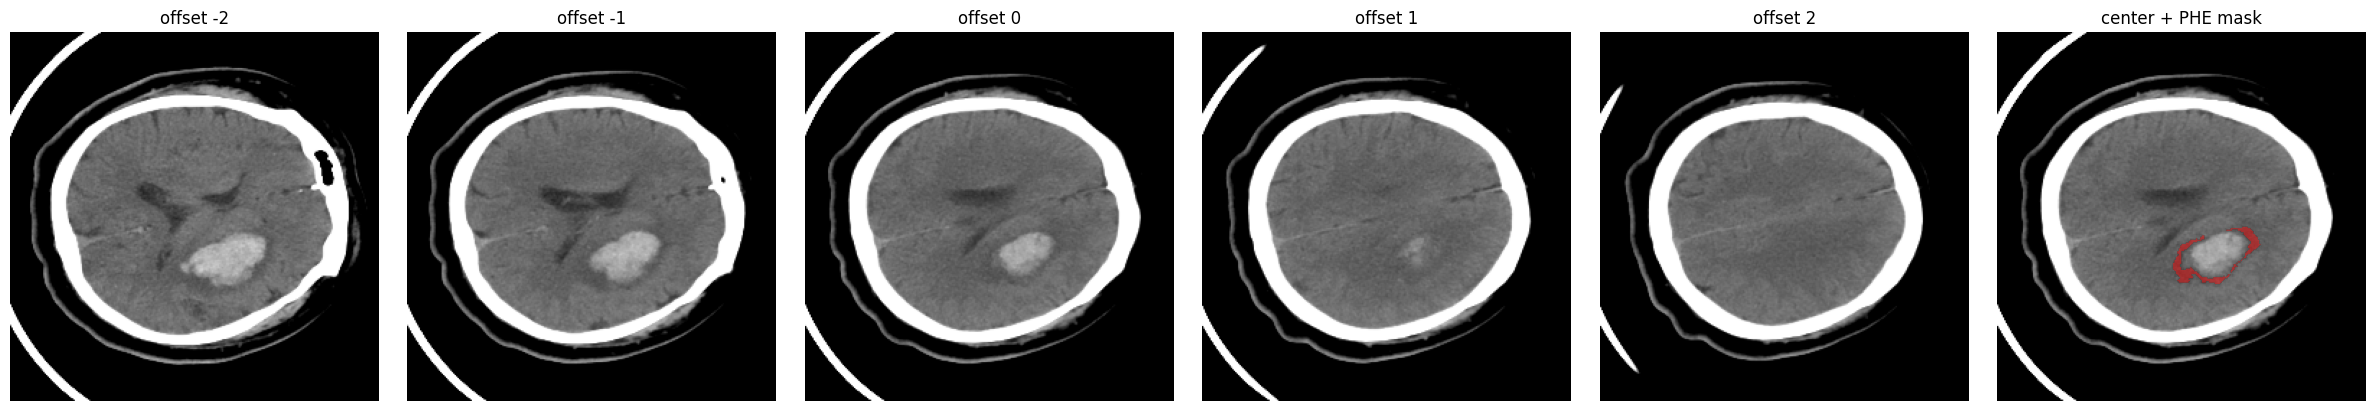

In [5]:
def brain_window(image: np.ndarray, low: float = CFG.brain_window_low, high: float = CFG.brain_window_high) -> np.ndarray:
    image = image.astype(np.float32, copy=False)
    image = np.clip(image, low, high)
    return ((image - low) / max(high - low, 1e-6)).astype(np.float32)


def resize_2d(array: np.ndarray, out_size: int, order: int = 1) -> np.ndarray:
    if array.shape[-2:] == (out_size, out_size):
        return array
    if not SCIPY_AVAILABLE:
        raise ImportError("Install scipy for resizing.")
    zoom_y = out_size / array.shape[-2]
    zoom_x = out_size / array.shape[-1]
    return ndimage.zoom(array, (zoom_y, zoom_x), order=order)


def make_25d_stack(volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    n_slices = volume.shape[2]
    channels = []
    for off in CFG.slice_offsets:
        zi = int(np.clip(z + int(off), 0, n_slices - 1))
        x = brain_window(np.asarray(volume[:, :, zi]))
        channels.append(resize_2d(x, image_size, order=1))
    return np.stack(channels, axis=0).astype(np.float32)


def preprocess_mask_slice(mask_volume: np.ndarray, z: int, image_size: int = CFG.image_size) -> np.ndarray:
    y = (np.asarray(mask_volume[:, :, z]) > 0).astype(np.float32)
    return (resize_2d(y, image_size, order=0) > 0.5).astype(np.float32)


def largest_mask_slice(mask_volume: np.ndarray) -> int:
    per_slice = (mask_volume > 0).reshape((-1, mask_volume.shape[2])).sum(axis=0)
    return int(np.argmax(per_slice))


sample_row = train_rows.sort_values("mask_volume_ml", ascending=False).iloc[0]
image, spacing, _ = load_nifti(Path(sample_row["img_path"]))
mask, _, _ = load_nifti(Path(sample_row["mask_path"]))
z = largest_mask_slice(mask)
stack = make_25d_stack(image, z, image_size=256)
y = preprocess_mask_slice(mask, z, image_size=256)

fig, axes = plt.subplots(1, CFG.stack_size + 1, figsize=(4 * (CFG.stack_size + 1), 4))
for i in range(CFG.stack_size):
    axes[i].imshow(stack[i], cmap="gray")
    axes[i].set_title(f"offset {CFG.slice_offsets[i]}")
    axes[i].axis("off")
axes[-1].imshow(stack[CFG.stack_size // 2], cmap="gray")
axes[-1].imshow(np.ma.masked_where(y == 0, y), cmap="autumn", alpha=0.45)
axes[-1].set_title("center + PHE mask")
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(FIG_DIR / "option_0s_sample_25d_mask.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. Benchmark-compatible metrics

In [6]:
def diagonal_distance(shape: Sequence[int], sampling: Optional[Sequence[float]] = None) -> float:
    if sampling is None:
        sampling = [1.0] * len(shape)
    return float(math.sqrt(sum(((int(s) - 1) * float(sp)) ** 2 for s, sp in zip(shape, sampling))))


def confusion_counts(pred: np.ndarray, target: np.ndarray):
    pred = pred.astype(bool)
    target = target.astype(bool)
    tp = int(np.logical_and(pred, target).sum())
    fp = int(np.logical_and(pred, ~target).sum())
    fn = int(np.logical_and(~pred, target).sum())
    tn = int(np.logical_and(~pred, ~target).sum())
    return tp, fp, fn, tn


def overlap_metrics(pred: np.ndarray, target: np.ndarray) -> Dict:
    tp, fp, fn, tn = confusion_counts(pred, target)
    if tp + fp + fn == 0:
        return {"dice": np.nan, "jaccard": np.nan, "precision": np.nan, "recall": np.nan, "tp": tp, "fp": fp, "fn": fn, "tn": tn}
    return {
        "dice": float((2 * tp) / (2 * tp + fp + fn)) if (2 * tp + fp + fn) else np.nan,
        "jaccard": float(tp / (tp + fp + fn)) if (tp + fp + fn) else np.nan,
        "precision": float(tp / (tp + fp)) if (tp + fp) else 0.0,
        "recall": float(tp / (tp + fn)) if (tp + fn) else 0.0,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
    }


def surface_mask(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(bool)
    if mask.sum() == 0:
        return mask
    structure = np.ones((3, 3), dtype=bool) if mask.ndim == 2 else ndimage.generate_binary_structure(3, 1)
    eroded = ndimage.binary_erosion(mask, structure=structure, border_value=0)
    return np.logical_xor(mask, eroded)


def hausdorff_distance(pred: np.ndarray, target: np.ndarray, sampling=None, empty_penalty: bool = True) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
    sp = surface_mask(pred)
    st = surface_mask(target)
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=sampling)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=sampling)
    d1 = dt_to_target[sp]
    d2 = dt_to_pred[st]
    if len(d1) == 0 or len(d2) == 0:
        return diagonal_distance(pred.shape, sampling) if empty_penalty else np.inf
    return float(max(d1.max(), d2.max()))


def normalized_surface_dice(pred: np.ndarray, target: np.ndarray, spacing: Tuple[float, float, float], tolerance_mm: float = CFG.nsd_tolerance_mm) -> float:
    pred = pred.astype(bool)
    target = target.astype(bool)
    if pred.sum() == 0 and target.sum() == 0:
        return np.nan
    if pred.sum() == 0 or target.sum() == 0:
        return 0.0
    sp = surface_mask(pred)
    st = surface_mask(target)
    dt_to_target = ndimage.distance_transform_edt(~st, sampling=spacing)
    dt_to_pred = ndimage.distance_transform_edt(~sp, sampling=spacing)
    pred_close = int((dt_to_target[sp] <= tolerance_mm).sum())
    target_close = int((dt_to_pred[st] <= tolerance_mm).sum())
    denom = int(sp.sum() + st.sum())
    return float((pred_close + target_close) / denom) if denom else np.nan


def volume_ml(mask: np.ndarray, spacing: Tuple[float, float, float]) -> float:
    return float((mask.astype(bool).sum() * np.prod(spacing)) / 1000.0)


def rvd_abs(pred: np.ndarray, target: np.ndarray) -> float:
    pred_vox = float(pred.astype(bool).sum())
    target_vox = float(target.astype(bool).sum())
    if target_vox == 0:
        return np.nan if pred_vox == 0 else np.inf
    return float(abs(pred_vox - target_vox) / target_vox)


def rvd_signed(pred: np.ndarray, target: np.ndarray) -> float:
    pred_vox = float(pred.astype(bool).sum())
    target_vox = float(target.astype(bool).sum())
    if target_vox == 0:
        return np.nan if pred_vox == 0 else np.inf
    return float((pred_vox - target_vox) / target_vox)


def r2_score_np(y_true: Sequence[float], y_pred: Sequence[float]) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    if len(y_true) < 2:
        return np.nan
    ss_res = float(((y_true - y_pred) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan


def summarize_metrics(df: pd.DataFrame, group_name: str, cols: Optional[List[str]] = None) -> pd.DataFrame:
    cols = cols or ["dice", "jaccard", "hd_px", "hd_mm", "precision", "recall", "dsc", "rvd", "nsd", "volume_abs_error_ml"]
    rows = []
    for col in cols:
        if col not in df.columns:
            continue
        values = pd.to_numeric(df[col], errors="coerce")
        finite = values.replace([np.inf, -np.inf], np.nan)
        rows.append({
            "group": group_name,
            "metric": col,
            "mean": finite.mean(),
            "std": finite.std(),
            "median": finite.median(),
            "n": int(finite.notna().sum()),
            "n_inf": int(np.isinf(values).sum()),
        })
    return pd.DataFrame(rows)

In [7]:
def evaluate_slice_predictions_for_case(row: pd.Series, pred_volume: np.ndarray, positive_gt_only: bool = False) -> pd.DataFrame:
    target, spacing, _ = load_nifti(Path(row["mask_path"]))
    target = target > 0
    pred = pred_volume.astype(bool)
    rows = []
    for z in range(target.shape[2]):
        if positive_gt_only and target[:, :, z].sum() == 0:
            continue
        m = overlap_metrics(pred[:, :, z], target[:, :, z])
        m["hd_px"] = hausdorff_distance(pred[:, :, z], target[:, :, z], sampling=None, empty_penalty=True)
        m["hd_mm"] = hausdorff_distance(pred[:, :, z], target[:, :, z], sampling=spacing[:2], empty_penalty=True)
        m["gt_positive"] = bool(target[:, :, z].sum() > 0)
        m["pred_positive"] = bool(pred[:, :, z].sum() > 0)
        rows.append({"scan_id": row["scan_id"], "slice_idx": z, **m})
    return pd.DataFrame(rows)


def evaluate_volume_prediction_for_case(row: pd.Series, pred_volume: np.ndarray) -> Dict:
    target, spacing, _ = load_nifti(Path(row["mask_path"]))
    target = target > 0
    pred = pred_volume.astype(bool)
    overlap = overlap_metrics(pred, target)
    pred_ml = volume_ml(pred, spacing)
    target_ml = volume_ml(target, spacing)
    return {
        "scan_id": row["scan_id"],
        "dsc": overlap["dice"],
        "jaccard_3d": overlap["jaccard"],
        "precision_3d": overlap["precision"],
        "recall_3d": overlap["recall"],
        "hd_mm": hausdorff_distance(pred, target, sampling=spacing, empty_penalty=True),
        "rvd": rvd_abs(pred, target),
        "rvd_signed": rvd_signed(pred, target),
        "nsd": normalized_surface_dice(pred, target, spacing),
        "pred_volume_ml": pred_ml,
        "target_volume_ml": target_ml,
        "volume_abs_error_ml": abs(pred_ml - target_ml),
        "volume_sq_error_ml2": (pred_ml - target_ml) ** 2,
    }

## 4. Dataset

In [8]:
if TORCH_AVAILABLE:
    class Phe25DSegDataset(Dataset):
        def __init__(self, df: pd.DataFrame, image_size: int = CFG.image_size, augment: bool = False):
            self.df = df.copy().reset_index(drop=True)
            self.image_size = int(image_size)
            self.augment = bool(augment)
            self.cache = {}
            self.slice_df = self._build_slice_index()

        def _build_slice_index(self):
            rows = []
            for row_idx, row in self.df.iterrows():
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                mask = mask > 0
                n = mask.shape[2]
                per_slice = mask.reshape((-1, n)).sum(axis=0)
                for z in range(n):
                    rows.append({
                        "row_idx": row_idx,
                        "scan_id": row["scan_id"],
                        "slice_idx": int(z),
                        "positive": bool(per_slice[z] > 0),
                        "mask_pixels": int(per_slice[z]),
                    })
            return pd.DataFrame(rows)

        def _load_case(self, row_idx: int):
            if row_idx not in self.cache:
                row = self.df.iloc[row_idx]
                image, spacing, _ = load_nifti(Path(row["img_path"]))
                mask, _, _ = load_nifti(Path(row["mask_path"]))
                self.cache[row_idx] = (image.astype(np.float32), (mask > 0).astype(np.uint8), spacing)
            return self.cache[row_idx]

        def _augment(self, x: np.ndarray, y: np.ndarray):
            if random.random() < 0.5:
                x = np.flip(x, axis=2).copy()
                y = np.flip(y, axis=1).copy()
            if random.random() < 0.18:
                angle = random.uniform(-8.0, 8.0)
                x = np.stack([ndimage.rotate(ch, angle, reshape=False, order=1, mode="nearest") for ch in x], axis=0)
                y = ndimage.rotate(y, angle, reshape=False, order=0, mode="nearest")
            if random.random() < 0.15:
                gamma = random.uniform(0.90, 1.10)
                x = np.clip(x, 0, 1) ** gamma
            if random.random() < 0.12:
                x = np.clip(x + np.random.normal(0, 0.010, size=x.shape).astype(np.float32), 0, 1)
            return x.astype(np.float32), (y > 0.5).astype(np.float32)

        def __len__(self):
            return len(self.slice_df)

        def __getitem__(self, idx):
            item = self.slice_df.iloc[idx]
            image, mask, spacing = self._load_case(int(item["row_idx"]))
            z = int(item["slice_idx"])
            x = make_25d_stack(image, z, self.image_size)
            y = preprocess_mask_slice(mask, z, self.image_size)
            if self.augment:
                x, y = self._augment(x, y)
            return {
                "image": torch.from_numpy(x).float(),
                "mask": torch.from_numpy(y[None]).float(),
                "scan_id": str(item["scan_id"]),
                "slice_idx": int(z),
                "spacing": torch.tensor(spacing, dtype=torch.float32),
                "positive": bool(item["positive"]),
            }
else:
    print("Torch unavailable. Dataset skipped.")

## 5. Model: 2D backbone per slice + 3D fusion + FPN segmentation decoder

In [9]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def load_resnet18_backbone():
        weights = None
        if CFG.pretrained_backbone:
            try:
                weights = ResNet18_Weights.DEFAULT
            except Exception:
                weights = None
        try:
            model = resnet18(weights=weights)
            print("ResNet18 weights:", "ImageNet" if weights is not None else "random")
        except Exception as exc:
            print("Could not load pretrained ResNet18; falling back to random:", exc)
            model = resnet18(weights=None)
        old_conv = model.conv1
        new_conv = nn.Conv2d(
            1,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        model.conv1 = new_conv
        return model


    class SliceResNet18Encoder(nn.Module):
        def __init__(self):
            super().__init__()
            base = load_resnet18_backbone()
            self.stem = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool)
            self.layer1 = base.layer1
            self.layer2 = base.layer2
            self.layer3 = base.layer3
            self.layer4 = base.layer4

        def forward(self, x):
            x = self.stem(x)
            c2 = self.layer1(x)
            c3 = self.layer2(c2)
            c4 = self.layer3(c3)
            c5 = self.layer4(c4)
            return {"c2": c2, "c3": c3, "c4": c4, "c5": c5}


    def gn(channels: int):
        groups = 8
        while channels % groups != 0 and groups > 1:
            groups //= 2
        return nn.GroupNorm(groups, channels)


    class Depthwise3DFusion(nn.Module):
        def __init__(self, channels: int, depth: int):
            super().__init__()
            self.depthwise = nn.Conv3d(channels, channels, kernel_size=(depth, 1, 1), groups=channels, bias=False)
            self.pointwise = nn.Sequential(
                nn.Conv2d(channels, channels, kernel_size=1, bias=False),
                gn(channels),
                nn.SiLU(inplace=True),
            )

        def forward(self, x):
            # x: [B, N, C, H, W]
            x = x.permute(0, 2, 1, 3, 4).contiguous()
            x = self.depthwise(x).squeeze(2)
            return self.pointwise(x)


    class FPN(nn.Module):
        def __init__(self, in_channels=(64, 128, 256, 512), out_channels=CFG.fpn_channels):
            super().__init__()
            self.laterals = nn.ModuleList([nn.Conv2d(c, out_channels, 1) for c in in_channels])
            self.smooth = nn.ModuleList([
                nn.Sequential(nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False), gn(out_channels), nn.SiLU(inplace=True))
                for _ in in_channels
            ])

        def forward(self, feats: Dict[str, torch.Tensor]):
            c2, c3, c4, c5 = feats["c2"], feats["c3"], feats["c4"], feats["c5"]
            lat = [l(f) for l, f in zip(self.laterals, [c2, c3, c4, c5])]
            p5 = lat[3]
            p4 = lat[2] + F.interpolate(p5, size=lat[2].shape[-2:], mode="nearest")
            p3 = lat[1] + F.interpolate(p4, size=lat[1].shape[-2:], mode="nearest")
            p2 = lat[0] + F.interpolate(p3, size=lat[0].shape[-2:], mode="nearest")
            return {
                "p2": self.smooth[0](p2),
                "p3": self.smooth[1](p3),
                "p4": self.smooth[2](p4),
                "p5": self.smooth[3](p5),
            }


    class ConvGNAct(nn.Module):
        def __init__(self, in_ch, out_ch, dropout=0.0):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                gn(out_ch),
                nn.SiLU(inplace=True),
                nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                gn(out_ch),
                nn.SiLU(inplace=True),
            )

        def forward(self, x):
            return self.net(x)


    class SegmentationDecoder(nn.Module):
        def __init__(self, fpn_channels=CFG.fpn_channels, decoder_channels=CFG.decoder_channels):
            super().__init__()
            d0, d1, d2, d3 = decoder_channels
            self.fuse = ConvGNAct(fpn_channels * 4, d0, dropout=0.08)
            self.up1 = ConvGNAct(d0, d1, dropout=0.05)
            self.up2 = ConvGNAct(d1, d2, dropout=0.03)
            self.up3 = ConvGNAct(d2, d3, dropout=0.02)
            self.head = nn.Conv2d(d3, 1, 1)

        def forward(self, pyramid: Dict[str, torch.Tensor]):
            p2 = pyramid["p2"]
            target_size = p2.shape[-2:]
            p3 = F.interpolate(pyramid["p3"], size=target_size, mode="bilinear", align_corners=False)
            p4 = F.interpolate(pyramid["p4"], size=target_size, mode="bilinear", align_corners=False)
            p5 = F.interpolate(pyramid["p5"], size=target_size, mode="bilinear", align_corners=False)
            x = self.fuse(torch.cat([p2, p3, p4, p5], dim=1))
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            x = self.up1(x)
            x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
            x = self.up2(x)
            x = self.up3(x)
            return self.head(x)


    class Phe25DFusionFPNSegModel(nn.Module):
        def __init__(self):
            super().__init__()
            self.encoder = SliceResNet18Encoder()
            self.fusions = nn.ModuleDict({
                "c2": Depthwise3DFusion(64, CFG.stack_size),
                "c3": Depthwise3DFusion(128, CFG.stack_size),
                "c4": Depthwise3DFusion(256, CFG.stack_size),
                "c5": Depthwise3DFusion(512, CFG.stack_size),
            })
            self.fpn = FPN()
            self.decoder = SegmentationDecoder()

        def forward(self, x):
            # x: [B, N, H, W]
            b, n, h, w = x.shape
            x2d = x.reshape(b * n, 1, h, w)
            per_slice = self.encoder(x2d)
            fused = {}
            for name, feat in per_slice.items():
                _, c, fh, fw = feat.shape
                feat = feat.reshape(b, n, c, fh, fw)
                fused[name] = self.fusions[name](feat)
            pyramid = self.fpn(fused)
            logits = self.decoder(pyramid)
            if logits.shape[-2:] != (h, w):
                logits = F.interpolate(logits, size=(h, w), mode="bilinear", align_corners=False)
            return logits
elif TORCH_AVAILABLE:
    print("Torch is available but torchvision is not. Install torchvision to run Option 0S.")
else:
    print("Torch unavailable. Model skipped.")

## 6. Loss and training setup

In [10]:
if TORCH_AVAILABLE:
    def dice_loss_from_logits(logits, targets, eps=1e-6):
        probs = torch.sigmoid(logits)
        dims = tuple(range(1, probs.ndim))
        inter = (probs * targets).sum(dims)
        union = probs.sum(dims) + targets.sum(dims)
        return 1.0 - ((2 * inter + eps) / (union + eps)).mean()


    def focal_tversky_loss(logits, targets, eps=1e-6):
        probs = torch.sigmoid(logits)
        dims = tuple(range(1, probs.ndim))
        tp = (probs * targets).sum(dims)
        fp = (probs * (1 - targets)).sum(dims)
        fn = ((1 - probs) * targets).sum(dims)
        tv = (tp + eps) / (tp + CFG.ftv_alpha * fp + CFG.ftv_beta * fn + eps)
        return ((1 - tv) ** CFG.ftv_gamma).mean()


    def boundary_consistency_loss(logits, targets):
        probs = torch.sigmoid(logits)
        px = torch.abs(probs[:, :, :, 1:] - probs[:, :, :, :-1])
        py = torch.abs(probs[:, :, 1:, :] - probs[:, :, :-1, :])
        tx = torch.abs(targets[:, :, :, 1:] - targets[:, :, :, :-1])
        ty = torch.abs(targets[:, :, 1:, :] - targets[:, :, :-1, :])
        return F.l1_loss(px, tx) + F.l1_loss(py, ty)


    def make_loss_fn(pos_weight_value: float):
        pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

        def loss_fn(logits, targets):
            bce = F.binary_cross_entropy_with_logits(logits, targets, pos_weight=pos_weight)
            return (
                CFG.lambda_bce * bce
                + CFG.lambda_dice * dice_loss_from_logits(logits, targets)
                + CFG.lambda_ftv * focal_tversky_loss(logits, targets)
                + CFG.lambda_boundary * boundary_consistency_loss(logits, targets)
            )

        return loss_fn


    def positive_pixel_weight(df: pd.DataFrame, clip: float = CFG.bce_pos_weight_clip):
        pos = 0
        total = 0
        for _, row in df.iterrows():
            mask, _, _ = load_nifti(Path(row["mask_path"]))
            pos += int((mask > 0).sum())
            total += int(np.prod(mask.shape))
        neg = max(total - pos, 1)
        return float(min(neg / max(pos, 1), clip))


    def make_loader(ds, batch_size, positive_weight, shuffle=False):
        if shuffle:
            weights = np.where(ds.slice_df["positive"].to_numpy(bool), positive_weight, 1.0).astype(np.float64)
            sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)
            return DataLoader(ds, batch_size=batch_size, sampler=sampler, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))
        return DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=CFG.num_workers, pin_memory=(DEVICE == "cuda"))


if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    train_ds = Phe25DSegDataset(train_rows, CFG.image_size, augment=CFG.augment_train)
    val_ds = Phe25DSegDataset(val_rows, CFG.image_size, augment=False)
    train_loader = make_loader(train_ds, CFG.batch_size, CFG.positive_slice_weight, shuffle=True)
    val_loader = make_loader(val_ds, CFG.batch_size, CFG.positive_slice_weight, shuffle=False)

    pos_weight_value = positive_pixel_weight(train_rows)
    model = Phe25DFusionFPNSegModel().to(DEVICE)
    loss_fn = make_loss_fn(pos_weight_value)
    backbone_params = list(model.encoder.parameters())
    head_params = [p for n, p in model.named_parameters() if not n.startswith("encoder.")]
    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": CFG.lr_backbone},
            {"params": head_params, "lr": CFG.lr_head},
        ],
        weight_decay=CFG.weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)

    display(pd.DataFrame([
        {"split": "train", "cases": len(train_rows), "slices": len(train_ds), "positive_slices": int(train_ds.slice_df["positive"].sum())},
        {"split": "val", "cases": len(val_rows), "slices": len(val_ds), "positive_slices": int(val_ds.slice_df["positive"].sum())},
        {"split": "test", "cases": len(test_rows), "slices": int(test_rows["n_slices"].sum()), "positive_slices": int(test_rows["positive_slices"].sum())},
    ]))
    print("pos_weight:", pos_weight_value)
    print("parameters:", sum(p.numel() for p in model.parameters()))
else:
    print("Training setup skipped.")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\AD/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:01<00:00, 27.4MB/s]


ResNet18 weights: ImageNet


,split,cases,slices,positive_slices
0,train,48,1368,284
1,val,48,1434,269
2,test,24,799,130


pos_weight: 25.0
parameters: 13312113


## 7. Train segmentation model

In [11]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def set_backbone_trainable(model, trainable: bool):
        for p in model.encoder.parameters():
            p.requires_grad = bool(trainable)


    def train_epoch(epoch: int):
        backbone_trainable = epoch > CFG.freeze_backbone_epochs
        set_backbone_trainable(model, backbone_trainable)
        model.train()
        if not backbone_trainable:
            model.encoder.eval()

        scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))
        losses = []
        optimizer.zero_grad(set_to_none=True)
        for step, batch in enumerate(tqdm(train_loader, desc=f"train {epoch}", leave=False), start=1):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["mask"].to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
                logits = model(x)
                loss = loss_fn(logits, y) / max(1, CFG.grad_accum_steps)
            scaler.scale(loss).backward()
            if step % CFG.grad_accum_steps == 0 or step == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            losses.append(float(loss.detach().cpu()) * max(1, CFG.grad_accum_steps))
        return float(np.mean(losses)) if losses else np.nan


    @torch.no_grad()
    def validate_slices():
        model.eval()
        losses, dices, precs, recs = [], [], [], []
        empty_total = 0
        empty_pred = 0
        for batch in tqdm(val_loader, desc="val", leave=False):
            x = batch["image"].to(DEVICE, non_blocking=True)
            y = batch["mask"].to(DEVICE, non_blocking=True)
            logits = model(x)
            losses.append(float(loss_fn(logits, y).detach().cpu()))
            prob = torch.sigmoid(logits).cpu().numpy()[:, 0]
            target = y.cpu().numpy()[:, 0] > 0
            pred = prob >= CFG.threshold
            for i in range(pred.shape[0]):
                if target[i].sum() > 0:
                    m = overlap_metrics(pred[i], target[i])
                    dices.append(m["dice"])
                    precs.append(m["precision"])
                    recs.append(m["recall"])
                else:
                    empty_total += 1
                    empty_pred += int(pred[i].sum() > 0)
        empty_fp_rate = empty_pred / max(empty_total, 1)
        dice_pos = float(np.nanmean(dices)) if dices else np.nan
        precision_pos = float(np.nanmean(precs)) if precs else np.nan
        recall_pos = float(np.nanmean(recs)) if recs else np.nan
        score = dice_pos - 0.20 * empty_fp_rate if np.isfinite(dice_pos) else np.nan
        return {
            "loss": float(np.mean(losses)) if losses else np.nan,
            "dice_pos": dice_pos,
            "precision_pos": precision_pos,
            "recall_pos": recall_pos,
            "empty_fp_rate": float(empty_fp_rate),
            "score": float(score) if np.isfinite(score) else np.nan,
        }


    best_ckpt = CHECKPOINT_DIR / "option_0s_fusion_fpn_seg_best.pt"
    last_ckpt = CHECKPOINT_DIR / "option_0s_fusion_fpn_seg_last.pt"

    if CFG.run_training:
        epochs = CFG.debug_epochs if CFG.debug_small_run else CFG.epochs
        history = []
        best = -np.inf
        bad = 0
        for epoch in range(1, epochs + 1):
            t0 = time.time()
            tr_loss = train_epoch(epoch)
            val_m = validate_slices()
            scheduler.step(val_m["score"] if np.isfinite(val_m["score"]) else 0.0)
            row = {
                "epoch": epoch,
                "lr_backbone": optimizer.param_groups[0]["lr"],
                "lr_head": optimizer.param_groups[1]["lr"],
                "backbone_trainable": epoch > CFG.freeze_backbone_epochs,
                "sec": time.time() - t0,
                "train_loss": tr_loss,
                **{f"val_{k}": v for k, v in val_m.items()},
            }
            history.append(row)
            print(row)
            pd.DataFrame(history).to_csv(LOG_DIR / "option_0s_training_log.csv", index=False)
            torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "history": history}, last_ckpt)

            score = val_m["score"]
            if np.isfinite(score) and score > best + CFG.min_delta:
                best = score
                bad = 0
                torch.save({"model": model.state_dict(), "cfg": asdict(CFG), "epoch": epoch, "best_metric": best, "history": history}, best_ckpt)
                print("Saved best:", best_ckpt)
            else:
                bad += 1
            if bad >= CFG.patience:
                print(f"Early stopping at epoch {epoch}; best val score={best:.4f}")
                break
    else:
        print("Training disabled.")
else:
    print("Training skipped.")

C:\Users\AD\AppData\Local\Temp\ipykernel_16992\2591023083.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


train 1:   0%|          | 0/684 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_16992\2591023083.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_16992\2591023083.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_16992\2591023083.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):
C:\Users\AD\AppData\Local\Temp\ipykernel_16992\2591023083.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(e

val:   0%|          | 0/717 [00:00<?, ?it/s]

{'epoch': 1, 'lr_backbone': 1e-05, 'lr_head': 5e-05, 'backbone_trainable': False, 'sec': 199.4783251285553, 'train_loss': 1.2979302550965583, 'val_loss': 1.2416928215173166, 'val_dice_pos': 0.11373638874422548, 'val_precision_pos': 0.07416707963247621, 'val_recall_pos': 0.6072964564080999, 'val_empty_fp_rate': 0.10300429184549356, 'val_score': 0.09313553037512677}
Saved best: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option_0s_phe_only_25d_fusion_fpn_segmentation\checkpoints\option_0s_fusion_fpn_seg_best.pt


...

C:\Users\AD\AppData\Local\Temp\ipykernel_16992\2591023083.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(CFG.amp and DEVICE == "cuda"))


train 30:   0%|          | 0/684 [00:00<?, ?it/s]

C:\Users\AD\AppData\Local\Temp\ipykernel_16992\2591023083.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(CFG.amp and DEVICE == "cuda")):


val:   0%|          | 0/717 [00:00<?, ?it/s]

{'epoch': 30, 'lr_backbone': 2.5e-06, 'lr_head': 1.25e-05, 'backbone_trainable': True, 'sec': 221.62416410446167, 'train_loss': 0.7633485829795313, 'val_loss': 1.108707811875656, 'val_dice_pos': 0.33016950378323795, 'val_precision_pos': 0.4540586889376576, 'val_recall_pos': 0.3669951336570252, 'val_empty_fp_rate': 0.2497854077253219, 'val_score': 0.28021242223817355}
Early stopping at epoch 30; best val score=0.3373


## 8. Threshold tuning and inference helpers

In [12]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE:
    def torch_load_checkpoint(path: Path):
        try:
            return torch.load(path, map_location=DEVICE, weights_only=False)
        except TypeError:
            return torch.load(path, map_location=DEVICE)


    def load_best_model():
        ckpt = CHECKPOINT_DIR / "option_0s_fusion_fpn_seg_best.pt"
        if not ckpt.exists():
            ckpt = CHECKPOINT_DIR / "option_0s_fusion_fpn_seg_last.pt"
        if not ckpt.exists():
            return None, None
        m = Phe25DFusionFPNSegModel().to(DEVICE)
        state = torch_load_checkpoint(ckpt)
        state_dict = state["model"] if isinstance(state, dict) and "model" in state else state
        m.load_state_dict(state_dict)
        m.eval()
        return m, ckpt


    @torch.no_grad()
    def predict_case_probability(m, row: pd.Series, image_size: int = CFG.image_size):
        m.eval()
        image, spacing, _ = load_nifti(Path(row["img_path"]))
        probs = []
        for z in range(image.shape[2]):
            x = make_25d_stack(image, z, image_size)
            xb = torch.from_numpy(x[None]).float().to(DEVICE)
            prob = torch.sigmoid(m(xb))[0, 0].detach().cpu().numpy()
            if CFG.use_tta_flip:
                xf = np.flip(x, axis=2).copy()
                xfb = torch.from_numpy(xf[None]).float().to(DEVICE)
                pf = torch.sigmoid(m(xfb))[0, 0].detach().cpu().numpy()
                pf = np.flip(pf, axis=1).copy()
                prob = 0.5 * (prob + pf)
            prob = resize_2d(prob, image.shape[0], order=1)
            if prob.shape != image.shape[:2]:
                prob = ndimage.zoom(prob, (image.shape[0] / prob.shape[0], image.shape[1] / prob.shape[1]), order=1)
            probs.append(prob.astype(np.float32))
        return np.stack(probs, axis=2), spacing


    def postprocess_prediction(pred: np.ndarray, spacing: Tuple[float, float, float]) -> np.ndarray:
        pred = pred.astype(bool)
        if not CFG.use_postprocess or pred.sum() == 0:
            return pred
        labeled, n = ndimage.label(pred)
        if n == 0:
            return pred
        sizes = np.bincount(labeled.ravel()).astype(np.float64)
        sizes[0] = 0
        min_voxels = max(1, int(round((CFG.min_component_ml * 1000.0) / np.prod(spacing))))
        keep = np.zeros(n + 1, dtype=bool)
        if CFG.keep_largest_component:
            keep[int(np.argmax(sizes))] = True
        else:
            candidates = np.where(sizes >= min_voxels)[0]
            candidates = candidates[candidates != 0]
            if len(candidates):
                order = candidates[np.argsort(sizes[candidates])[::-1]]
                keep[order[:CFG.max_components]] = True
        return keep[labeled]


    def fast_volume_metrics_from_arrays(prob: np.ndarray, target: np.ndarray, spacing, threshold: float):
        pred = postprocess_prediction(prob >= float(threshold), spacing)
        target = target.astype(bool)
        overlap = overlap_metrics(pred, target)
        pred_ml = volume_ml(pred, spacing)
        target_ml = volume_ml(target, spacing)
        return {
            "dsc": overlap["dice"],
            "precision": overlap["precision"],
            "recall": overlap["recall"],
            "rvd": rvd_abs(pred, target),
            "rvd_signed": rvd_signed(pred, target),
            "pred_volume_ml": pred_ml,
            "target_volume_ml": target_ml,
            "volume_abs_error_ml": abs(pred_ml - target_ml),
        }


    eval_model, used_ckpt = load_best_model()
    tuned_threshold = CFG.threshold
    threshold_table = pd.DataFrame()

    if eval_model is not None and CFG.tune_threshold_on_val:
        sweep_rows = [
            {
                "threshold": float(t),
                "mean_dsc": [],
                "mean_precision": [],
                "mean_recall": [],
                "mean_rvd": [],
                "mean_rvd_signed": [],
                "volume_mae_ml": [],
            }
            for t in CFG.threshold_grid
        ]
        for _, row in tqdm(val_rows.iterrows(), total=len(val_rows), desc="threshold val"):
            prob, spacing = predict_case_probability(eval_model, row)
            target, _, _ = load_nifti(Path(row["mask_path"]))
            target = target > 0
            for item in sweep_rows:
                m = fast_volume_metrics_from_arrays(prob, target, spacing, item["threshold"])
                item["mean_dsc"].append(m["dsc"])
                item["mean_precision"].append(m["precision"])
                item["mean_recall"].append(m["recall"])
                item["mean_rvd"].append(m["rvd"])
                item["mean_rvd_signed"].append(m["rvd_signed"])
                item["volume_mae_ml"].append(m["volume_abs_error_ml"])

        compact = []
        for item in sweep_rows:
            mean_dsc = float(pd.Series(item["mean_dsc"]).replace([np.inf, -np.inf], np.nan).mean())
            mean_rvd = float(pd.Series(item["mean_rvd"]).replace([np.inf, -np.inf], np.nan).mean())
            volume_mae = float(pd.Series(item["volume_mae_ml"]).replace([np.inf, -np.inf], np.nan).mean())
            overvol = max(0.0, float(pd.Series(item["mean_rvd_signed"]).replace([np.inf, -np.inf], np.nan).mean()))
            score = mean_dsc - CFG.threshold_rvd_penalty * mean_rvd - CFG.threshold_volume_mae_penalty * volume_mae - 0.02 * overvol
            compact.append({
                "threshold": item["threshold"],
                "mean_dsc": mean_dsc,
                "mean_precision": float(pd.Series(item["mean_precision"]).replace([np.inf, -np.inf], np.nan).mean()),
                "mean_recall": float(pd.Series(item["mean_recall"]).replace([np.inf, -np.inf], np.nan).mean()),
                "mean_rvd": mean_rvd,
                "mean_rvd_signed": float(pd.Series(item["mean_rvd_signed"]).replace([np.inf, -np.inf], np.nan).mean()),
                "volume_mae_ml": volume_mae,
                "selection_score": float(score),
            })
        threshold_table = pd.DataFrame(compact)
        threshold_table.to_csv(TABLE_DIR / "option_0s_val_threshold_sweep.csv", index=False)
        tuned_threshold = float(
            threshold_table.sort_values(
                ["selection_score", "mean_dsc", "volume_mae_ml", "mean_rvd"],
                ascending=[False, False, True, True],
            ).iloc[0]["threshold"]
        )
        print("Loaded checkpoint:", used_ckpt)
        print("Tuned threshold:", tuned_threshold)
        display(threshold_table)
    elif eval_model is None:
        print("No checkpoint found for threshold tuning.")
    else:
        print("Threshold tuning disabled; using", tuned_threshold)

    with open(LOG_DIR / "option_0s_threshold.json", "w", encoding="utf-8") as f:
        json.dump(
            {
                "threshold": tuned_threshold,
                "default_threshold": CFG.threshold,
                "checkpoint": str(used_ckpt) if used_ckpt else None,
                "selection_metric": "validation mean DSC penalized by RVD, volume MAE, and over-volume",
                "postprocess": {
                    "enabled": CFG.use_postprocess,
                    "min_component_ml": CFG.min_component_ml,
                    "max_components": CFG.max_components,
                    "keep_largest_component": CFG.keep_largest_component,
                },
            },
            f,
            ensure_ascii=False,
            indent=2,
        )
else:
    print("Threshold tuning skipped.")

ResNet18 weights: ImageNet


threshold val:   0%|          | 0/48 [00:00<?, ?it/s]

Loaded checkpoint: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option_0s_phe_only_25d_fusion_fpn_segmentation\checkpoints\option_0s_fusion_fpn_seg_best.pt
Tuned threshold: 0.5


,threshold,mean_dsc,mean_precision,mean_recall,mean_rvd,mean_rvd_signed,volume_mae_ml,selection_score
0,0.30,0.346794,0.309152,0.559330,2.830345,2.614397,2.893597,0.166825
1,0.35,0.345458,0.314351,0.545265,2.698397,2.467402,2.762458,0.174361
2,0.40,0.345756,0.321587,0.532410,2.558812,2.313076,2.608864,0.184097
3,0.45,0.346795,0.331345,0.516376,2.374426,2.109094,2.428319,0.197495
4,0.50,0.341035,0.357050,0.465096,1.921394,1.534454,2.099922,0.222990
5,0.55,0.318094,0.364770,0.404429,1.631231,1.093731,2.053913,0.220701
6,0.60,0.312641,0.371276,0.383809,1.528473,0.942910,2.065575,0.222316
7,0.65,0.308619,0.379043,0.369768,1.470958,0.835842,2.102287,0.222553
8,0.70,0.303677,0.383457,0.357046,1.416214,0.744796,2.131233,0.221476
9,0.75,0.297823,0.388211,0.342242,1.379286,0.649424,2.166187,0.218832


## 9. Final test evaluation

In [13]:
if TORCH_AVAILABLE and TORCHVISION_AVAILABLE and CFG.run_final_eval:
    if "eval_model" not in globals() or eval_model is None:
        eval_model, used_ckpt = load_best_model()
    if "tuned_threshold" not in globals():
        tuned_threshold = CFG.threshold

    if eval_model is not None:
        slice_parts = []
        volume_rows = []
        qualitative_cases = []
        for _, row in tqdm(test_rows.iterrows(), total=len(test_rows), desc="test volumes"):
            prob, spacing = predict_case_probability(eval_model, row)
            pred = postprocess_prediction(prob >= tuned_threshold, spacing)
            if CFG.save_probability_npz:
                np.savez_compressed(PRED_DIR / f"{row['scan_id']}_prob.npz", prob=prob.astype(np.float16), threshold=tuned_threshold)

            s_all = evaluate_slice_predictions_for_case(row, pred, positive_gt_only=False)
            s_pos = evaluate_slice_predictions_for_case(row, pred, positive_gt_only=True)
            s_all["slice_set"] = "all_slices_empty_empty_nan"
            s_pos["slice_set"] = "positive_gt_only"
            slice_parts.extend([s_all, s_pos])
            volume_rows.append(evaluate_volume_prediction_for_case(row, pred))

            if len(qualitative_cases) < 6:
                target, _, _ = load_nifti(Path(row["mask_path"]))
                z = largest_mask_slice(target)
                image, _, _ = load_nifti(Path(row["img_path"]))
                img_small = make_25d_stack(image, z, image_size=256)[CFG.stack_size // 2]
                gt_small = resize_2d((target[:, :, z] > 0).astype(np.float32), 256, order=0) > 0.5
                pred_small = resize_2d(pred[:, :, z].astype(np.float32), 256, order=0) > 0.5
                prob_small = resize_2d(prob[:, :, z].astype(np.float32), 256, order=1)
                qualitative_cases.append((row["scan_id"], img_small, gt_small, pred_small, prob_small))

        option0s_slice_df = pd.concat(slice_parts, ignore_index=True)
        option0s_volume_df = pd.DataFrame(volume_rows)
        option0s_slice_df.to_csv(TABLE_DIR / "option_0s_legacy_slice_metrics.csv", index=False)
        option0s_volume_df.to_csv(TABLE_DIR / "option_0s_volume_metrics.csv", index=False)

        legacy_summary = pd.concat([
            summarize_metrics(part, f"option_0s:{slice_set}", cols=["dice", "jaccard", "hd_px", "hd_mm", "precision", "recall"])
            for slice_set, part in option0s_slice_df.groupby("slice_set")
        ], ignore_index=True)
        volume_summary = summarize_metrics(
            option0s_volume_df,
            "option_0s:volume",
            cols=["dsc", "jaccard_3d", "hd_mm", "rvd", "nsd", "precision_3d", "recall_3d", "volume_abs_error_ml"],
        )
        volume_rmse = float(np.sqrt(option0s_volume_df["volume_sq_error_ml2"].mean()))
        volume_r2 = r2_score_np(option0s_volume_df["target_volume_ml"], option0s_volume_df["pred_volume_ml"])
        volume_summary = pd.concat([volume_summary, pd.DataFrame([
            {"group": "option_0s:volume", "metric": "volume_rmse_ml", "mean": volume_rmse, "std": np.nan, "median": np.nan, "n": len(option0s_volume_df), "n_inf": 0},
            {"group": "option_0s:volume", "metric": "volume_r2", "mean": volume_r2, "std": np.nan, "median": np.nan, "n": len(option0s_volume_df), "n_inf": 0},
        ])], ignore_index=True)

        legacy_summary.to_csv(TABLE_DIR / "option_0s_legacy_slice_summary.csv", index=False)
        volume_summary.to_csv(TABLE_DIR / "option_0s_volume_summary.csv", index=False)
        display(legacy_summary)
        display(volume_summary)
    else:
        print("No model checkpoint found.")
else:
    print("Final eval skipped.")

test volumes:   0%|          | 0/24 [00:00<?, ?it/s]

,group,metric,mean,std,median,n,n_inf
0,option_0s:all_slices_empty_empty_nan,dice,0.299695,0.233249,0.304628,149,0
1,option_0s:all_slices_empty_empty_nan,jaccard,0.199105,0.168812,0.179682,149,0
2,option_0s:all_slices_empty_empty_nan,hd_px,193.920726,283.828186,49.365980,149,0
3,option_0s:all_slices_empty_empty_nan,hd_mm,93.791364,138.897114,24.020261,149,0
4,option_0s:all_slices_empty_empty_nan,precision,0.360579,0.299329,0.380000,149,0
5,option_0s:all_slices_empty_empty_nan,recall,0.378528,0.314659,0.392796,149,0
6,option_0s:positive_gt_only,dice,0.343497,0.217384,0.365148,130,0
7,option_0s:positive_gt_only,jaccard,0.228205,0.161253,0.223352,130,0
8,option_0s:positive_gt_only,hd_px,116.642990,212.670482,42.583052,130,0
9,option_0s:positive_gt_only,hd_mm,56.252788,104.806648,20.115718,130,0


,group,metric,mean,std,median,n,n_inf
0,option_0s:volume,dsc,0.329994,0.181344,0.299527,24,0
1,option_0s:volume,jaccard_3d,0.211062,0.129959,0.176208,24,0
2,option_0s:volume,hd_mm,57.801164,129.845679,19.502160,24,0
3,option_0s:volume,rvd,1.408671,2.329620,0.638490,24,0
4,option_0s:volume,nsd,0.443830,0.228165,0.472068,24,0
5,option_0s:volume,precision_3d,0.385389,0.245232,0.381354,24,0
6,option_0s:volume,recall_3d,0.426057,0.238225,0.424900,24,0
7,option_0s:volume,volume_abs_error_ml,2.977652,4.449964,1.645603,24,0
8,option_0s:volume,volume_rmse_ml,5.276694,NaN,NaN,24,0
9,option_0s:volume,volume_r2,-0.136223,NaN,NaN,24,0


## 10. Compare with previous segmentation options

In [14]:
def load_summary(path: Path, label: str, metrics: Sequence[str]):
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    rows = []
    for metric in metrics:
        part = df[df["metric"] == metric]
        if len(part):
            rows.append({"option": label, "metric": metric, "mean": float(part.iloc[0]["mean"]), "median": float(part.iloc[0]["median"]) if "median" in part else np.nan})
    return pd.DataFrame(rows)


compare_parts = [
    load_summary(PROJECT_ROOT / "outputs_option1_phe_sich_2d_unet" / "tables" / "option1_volume_summary.csv", "option1", ["dsc", "hd_mm", "rvd", "nsd", "precision_3d", "recall_3d", "volume_abs_error_ml"]),
    load_summary(PROJECT_ROOT / "outputs_option1_1_phe_only_strong_2d" / "tables" / "option1_1_volume_summary.csv", "option1_1", ["dsc", "hd_mm", "rvd", "nsd", "precision_3d", "recall_3d", "volume_abs_error_ml"]),
    load_summary(PROJECT_ROOT / "outputs_option5_ring_prior_warmstart" / "tables" / "option5_volume_summary.csv", "option5", ["dsc", "hd_mm", "rvd", "nsd", "precision_3d", "recall_3d", "volume_abs_error_ml"]),
    load_summary(TABLE_DIR / "option_0s_volume_summary.csv", "option_0s", ["dsc", "hd_mm", "rvd", "nsd", "precision_3d", "recall_3d", "volume_abs_error_ml"]),
]
compare_df = pd.concat([p for p in compare_parts if len(p)], ignore_index=True) if any(len(p) for p in compare_parts) else pd.DataFrame()
if len(compare_df):
    compare_pivot = compare_df.pivot(index="metric", columns="option", values="mean")
    compare_pivot.to_csv(TABLE_DIR / "option_0s_compare_volume_summary.csv")
    display(compare_pivot)
else:
    print("No comparison summaries available yet.")

option,option1,option1_1,option5,option_0s
metric,,,,
dsc,0.382606,0.369361,0.379485,0.329994
hd_mm,49.758531,95.380818,44.662162,57.801164
nsd,0.512313,0.475643,0.505481,0.443830
precision_3d,0.382147,0.305796,0.397632,0.385389
recall_3d,0.568731,0.647108,0.532747,0.426057
rvd,1.857140,2.752385,1.583174,1.408671
volume_abs_error_ml,2.990255,4.072965,2.807575,2.977652


## 11. Qualitative figures and protocol

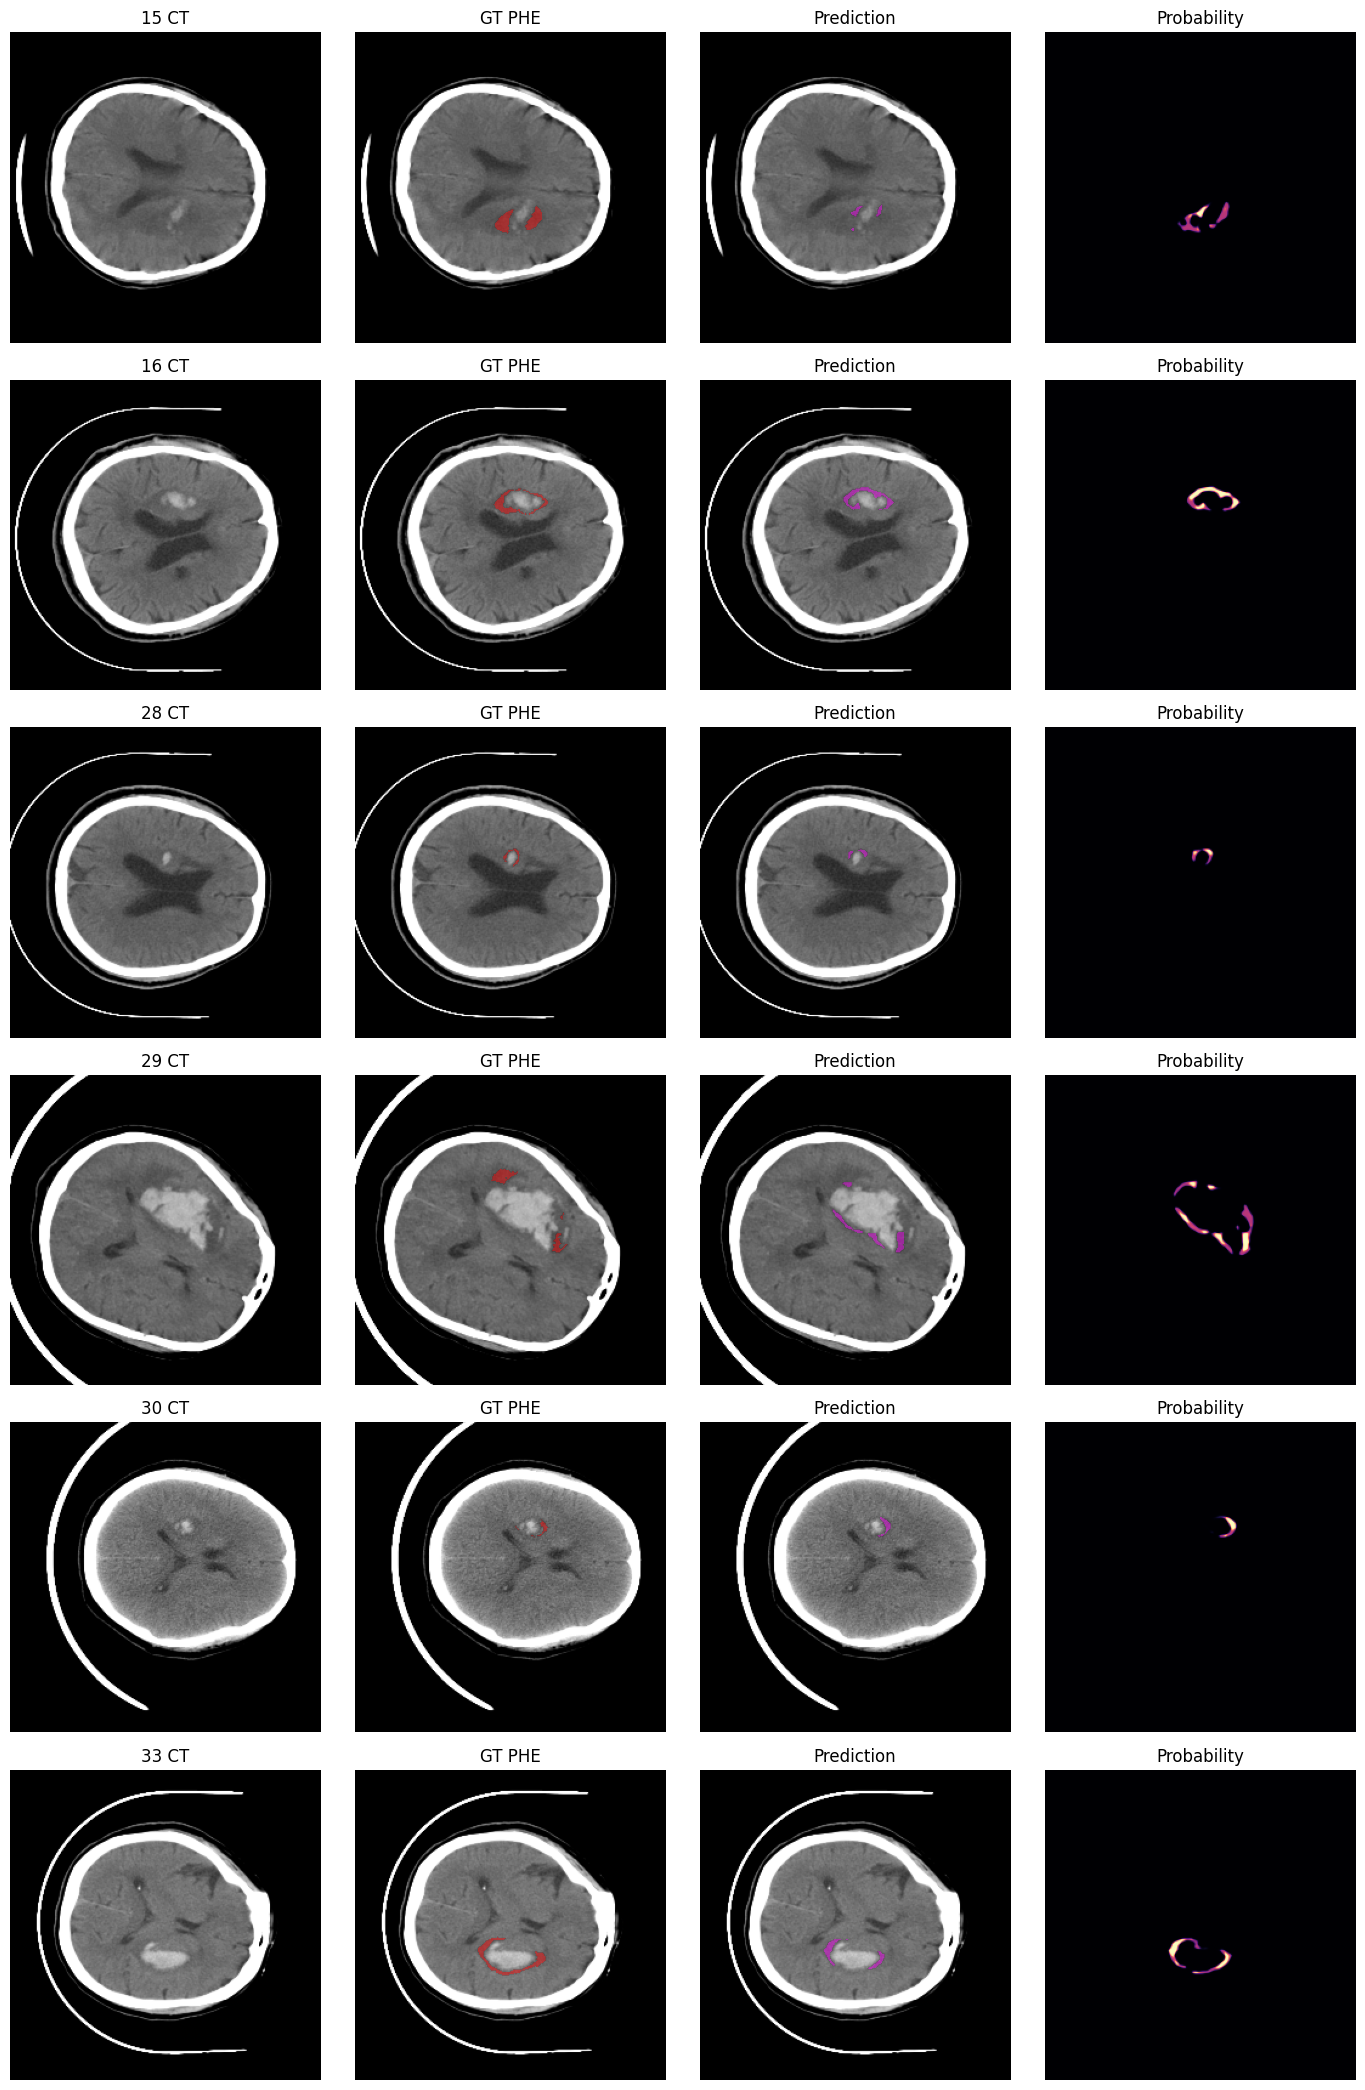

Saved protocol: D:\Thuy_Loi\Nam_3\CT_xuathuyetnao\outputs_option_0s_phe_only_25d_fusion_fpn_segmentation\logs\option_0s_protocol.json


In [15]:
if "qualitative_cases" in globals() and len(qualitative_cases):
    n = len(qualitative_cases)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
    if n == 1:
        axes = axes[None, :]
    for r, (scan_id, img_small, gt_small, pred_small, prob_small) in enumerate(qualitative_cases):
        axes[r, 0].imshow(img_small, cmap="gray")
        axes[r, 0].set_title(f"{scan_id} CT")
        axes[r, 1].imshow(img_small, cmap="gray")
        axes[r, 1].imshow(np.ma.masked_where(gt_small == 0, gt_small), cmap="autumn", alpha=0.45)
        axes[r, 1].set_title("GT PHE")
        axes[r, 2].imshow(img_small, cmap="gray")
        axes[r, 2].imshow(np.ma.masked_where(pred_small == 0, pred_small), cmap="spring", alpha=0.45)
        axes[r, 2].set_title("Prediction")
        axes[r, 3].imshow(prob_small, cmap="magma", vmin=0, vmax=1)
        axes[r, 3].set_title("Probability")
        for c in range(4):
            axes[r, c].axis("off")
    plt.tight_layout()
    fig.savefig(FIG_DIR / "option_0s_qualitative_predictions.png", dpi=160, bbox_inches="tight")
    plt.show()
else:
    print("No qualitative cases available. Run final evaluation first.")


protocol = {
    "option": "Option 0S - PHE-only 2.5D Fusion-FPN Segmentation",
    "task": "PHE mask segmentation, not detection",
    "data": "PHE-SICH-CT-IDS only",
    "no_source_ich": True,
    "no_seg_cq500": True,
    "no_instance": True,
    "split": "Reuse Option 1 patient-level 4:4:2 split",
    "architecture": {
        "input": f"2.5D stack with offsets {list(CFG.slice_offsets)}",
        "backbone": "2D ResNet18 applied per slice",
        "fusion": "depthwise Conv3D over stacked feature maps at each scale",
        "neck": "FPN",
        "head": "segmentation decoder/head",
    },
    "loss": "BCEWithLogits + Dice + Focal-Tversky + boundary consistency",
    "metrics": [
        "Dice/Jaccard/HD/Precision/Recall slice-level",
        "DSC/Jaccard3D/HD/RVD/NSD/volume error volume-level",
    ],
}
with open(LOG_DIR / "option_0s_protocol.json", "w", encoding="utf-8") as f:
    json.dump(protocol, f, ensure_ascii=False, indent=2, default=str)
print("Saved protocol:", LOG_DIR / "option_0s_protocol.json")